# Markov chain represented by a finite state-machine


In [2]:
import importlib
import numpy as np
from enum import Enum
import pandas as pd
import scr.custom_plot as cp
import scr.gillespie_algorithm as ga
import scr.transitions as tr
import scr.jablonski_animation as ja
import scr.processing as pr
import scr.fluorophore_systems as fs
import scr.initialize as init
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as manimation

In [212]:
importlib.reload(cp)
importlib.reload(ga)
importlib.reload(tr)
importlib.reload(ja)
importlib.reload(pr)
importlib.reload(init)
importlib.reload(fs)

<module 'scr.fluorophore_systems' from 'C:\\Users\\vie43sq\\OneDrive - Universität Würzburg\\GitHub\\MarkovModels\\notebooks\\scr\\fluorophore_systems.py'>

# Two fluorophore system

## Prerequisites

### All possible state combinations

In [141]:
states = ["S0", "S1", "T1", "R", "B"]
state_pairs = [(state_1, state_2) for state_1 in states for state_2 in states]
Joined_States = Enum("Joined_States", [f"{state_1}_{state_2}" for state_1, state_2 in state_pairs], start=0)
all_names = []
all_values = []
for joined_state in Joined_States:
    all_names.append(joined_state.name)
    all_values.append(joined_state.value)
all_states = pd.DataFrame([all_names, all_values])
all_states

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,S0_S0,S0_S1,S0_T1,S0_R,S0_B,S1_S0,S1_S1,S1_T1,S1_R,S1_B,...,R_S0,R_S1,R_T1,R_R,R_B,B_S0,B_S1,B_T1,B_R,B_B
1,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24


### All (im-)possible combined state transitions

In [142]:
transition_pairs = [(joined_state_1.name, joined_state_2.name) for joined_state_1 in Joined_States for joined_state_2 in Joined_States]
transitions = {f"{joined_state_1}__{joined_state_2}": (i//len(Joined_States), i%len(Joined_States)) 
               for i, (joined_state_1, joined_state_2) in enumerate(transition_pairs)}

### Transition rates

In [143]:
k_S0_S1 = k_exc = 1e4  # excitation
k_S1_S0 = k_em = 1e8  # emission
k_S1_T1 = k_isc = 1e6  # intersystem crossing
k_T1_S0 = k_pho = 1e5  # phosphorescence
k_S1_B = k_ble = 1e3  # bleaching
k_T1_R = k_red = 1e4  # reduction
k_R_S0_1 = k_ox = 0.5e0  # oxidation
k_R_S0_2 = k_ind = 0  #1e6  # induction (theory)

In [ ]:
rates = dict()  # Step 2: For the given state of the system, calculate the transition rates

rates = tr.rate_assignment(rates, transitions, "S0", "S1", k_S0_S1)
rates = tr.rate_assignment(rates, transitions, "S1", "S0", k_S1_S0)
rates = tr.rate_assignment(rates, transitions, "S1", "T1", k_S1_T1)
rates = tr.rate_assignment(rates, transitions, "T1", "S0", k_T1_S0)
rates = tr.rate_assignment(rates, transitions, "S1", "B", k_S1_B)
rates = tr.rate_assignment(rates, transitions, "T1", "R", k_T1_R)
rates = tr.rate_assignment(rates, transitions, "R", "S0", k_R_S0_1)

# only one of the two state pairs changes at a time 
# an exception is the theoretical induction of R to S0 by S1 to S0, defined in the following

rates["S1_R__S0_S0"] = k_R_S0_2
rates["R_S1__S0_S0"] = k_R_S0_2

### Transition matrix

In [146]:
transition_matrix, transition_rate_matrix, row_sums = tr.transition_matrix(rates, transitions, number=2)

### Initial row vector

In [148]:
initial_row_vector = np.zeros(shape=25) 
initial_row_vector[0] = 1

## Simulation of continous time markov chain CTMC

### Gillespie algorithm

In [115]:
%%time
time_series, time_step_series, state_series = ga.simulation_ctmc_gillespie(row_sums, initial_row_vector, 
                                                                           transition_matrix, 1000000, 90)

CPU times: total: 9.98 s
Wall time: 9.97 s


### Animation

In [10]:
ja.jablonski_animation(time_series, time_step_series, state_series, index_min=2300)

HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="writer_test.mp4" type="video/mp4">
</video></div>""")

## Processing

To this point we have a time and state series of the two fluorophore system. To create meaningful figures, some processing has to be done. 

### All photon emitting transitions
If an excited state S1 transitions to the ground state S0, a photon is emitted. An exception is if the transition is accompanied by a transition of a dark, reduced state to the ground state. The latter is the transition supposed to be responsible for recent experimental observations.

In [116]:
emitting_transitions, emitting_transitions_indices = pr.identify_emitting_transitions(transitions)

### The photon emitting states and times 

In [117]:
emitting_mask = pr.emitting_mask(state_series, emitting_transitions_indices)
events_at = time_series[emitting_mask]  # the time points at which the photon emission occurs
events_after = time_step_series[emitting_mask]  # the individual durations it took from S1 to S0
state_after_event = state_series[emitting_mask]  # the two-fluorophore states following the emission

### Unique states
For some analyses mirrored states (e.g., S0_S1 and S1_S0) should be condensed to one

In [118]:
duplices = pr.identify_duplices(all_names)
unique_states = pr.unique_states(duplices, state_series)

### Means and totals of state occupation times

In [119]:
total_times, mean_times, uniques = pr.occupation_times(time_step_series, unique_states)

### Unique state values adjusted
If there are, e.g., 15 occuring unique states, their identities will get adjusted such that, e.g., the maximum values is converted to 14 and their minimum value is converted to 0. This is useful to display them in a histogram with no gaps.

In [120]:
unique_states_converted = pr.convert_unique_states(uniques, unique_states)

### Resampling

In [121]:
resampled_time_series_5ms = pr.pandas_event_time_series(events_at, "s", "5ms")
measureable_rts_5ms = resampled_time_series_5ms[resampled_time_series_5ms!=0]

### Fluorescence correlation spectroscopy

In [122]:
autocorrelation = np.correlate(resampled_time_series_5ms.values, resampled_time_series_5ms.values, mode="full")
autocorrelation = autocorrelation[autocorrelation.size//2:]

#### With normalization

In [123]:
mean_intensity = np.mean(resampled_time_series_5ms.values)
deviation = resampled_time_series_5ms.values - mean_intensity
norm_corr = np.correlate(deviation, deviation, mode="full") / mean_intensity**2
norm_corr = norm_corr[norm_corr.size//2:]

## Figures

### Probability density distribution of state population

#### All states (including mirrored states)

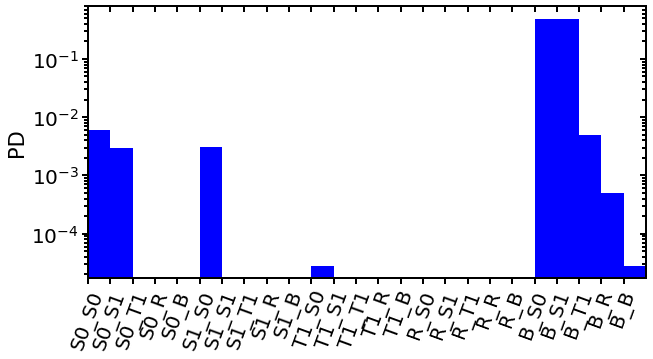

In [107]:
fig, ax = cp.universal_figure(type_="hist", data=state_series, ylabel="PD", xlabel=None,
                              xlim=[0, len(Joined_States)], xticks=range(len(Joined_States)), 
                              xticklabels=dict(labels=[joined_state.name for joined_state in Joined_States], 
                                               rotation=70), 
                              bins=np.arange(0, len(Joined_States)+1, 1), density=True, log=True)

#### Unique states only (mirrored states were condensed)

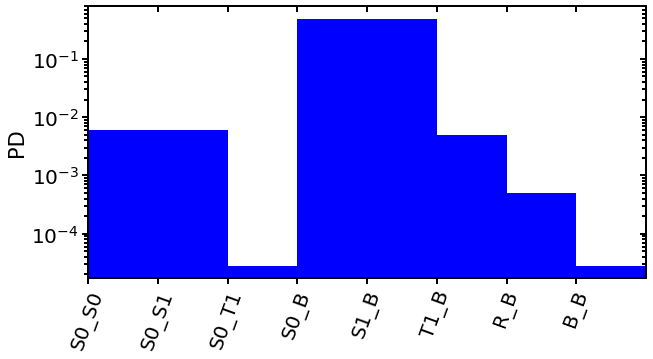

In [108]:
fig, ax = cp.universal_figure(type_="hist", data=unique_states_converted, ylabel="PD", xlabel=None,
                              xlim=[0, len(uniques)], xticks=range(len(uniques)), 
                              xticklabels=dict(labels=[joined_state.name for joined_state in Joined_States 
                                                       if joined_state.value in uniques], rotation=70),
                              bins=np.arange(0, len(uniques)+1, 1), density=True, log=True)

### Probability density distribution of time steps

#### All time steps

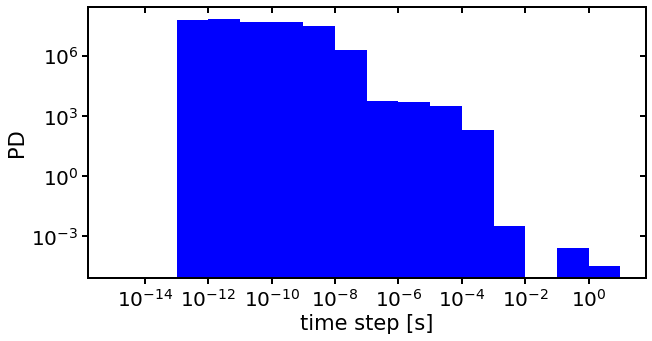

In [109]:
fig, ax = cp.universal_figure(type_="hist", data=time_step_series, ylabel="PD", xlabel="time step [s]",
                              xscale="log", bins=10**(np.arange(-15, 2, dtype=np.float64)), density=True, log=True)

#### All time steps of photon emitting transitions

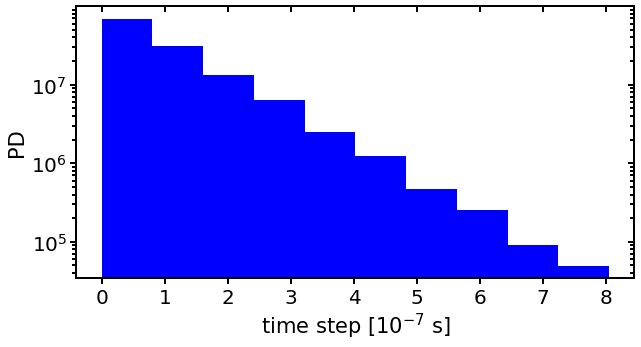

In [110]:
fig, ax = cp.universal_figure(type_="hist", data=events_after, ylabel="PD", xlabel="time step [$10^{-7}$ s]",
                              density=True, log=True, tick_style_x="sci")

### State occupation times

#### Mean state occupation times 

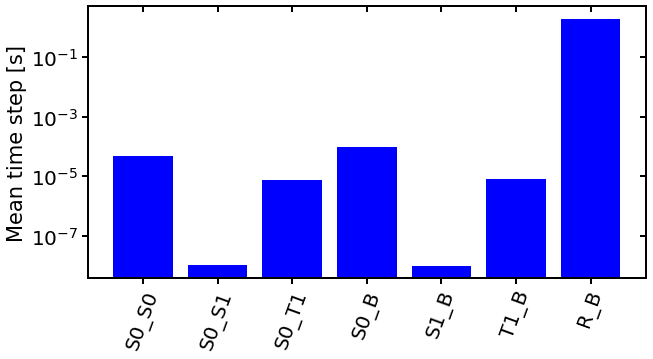

In [111]:
fig, ax = cp.universal_figure(type_="bar", data=[np.arange(len(uniques)), mean_times], ylabel="Mean time step [s]",
                              xlabel=None, yscale="log", xticks=range(len(uniques)), 
                              xticklabels=dict(labels=[joined_state.name for joined_state in Joined_States 
                                                       if joined_state.value in uniques], rotation=70))

#### Total state occupation times

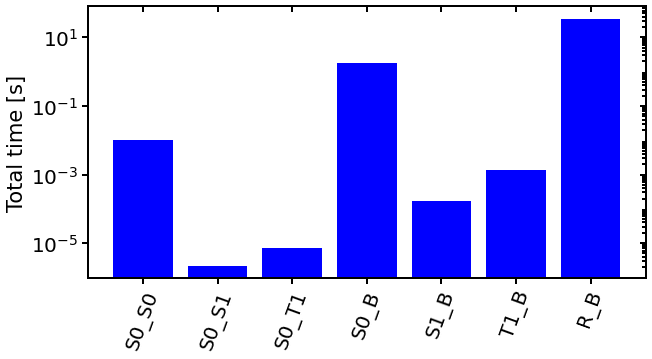

In [112]:
fig, ax = cp.universal_figure(type_="bar", data=[np.arange(len(uniques)), total_times], ylabel="Total time [s]", 
                              xlabel=None, yscale="log", xticks=range(len(uniques)), 
                              xticklabels=dict(labels=[joined_state.name for joined_state in Joined_States 
                                                       if joined_state.value in uniques], rotation=70))

### Events (emissions) resampled

#### Time series

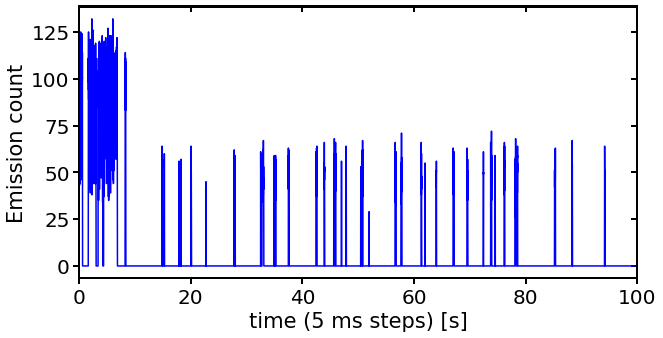

In [124]:
fig, ax = cp.universal_figure(type_="line", data=[resampled_time_series_5ms.index, resampled_time_series_5ms.values], 
                              ylabel="Emission count", 
                              xlabel="time (5 ms steps) [s]", xlim=[0, 100])

#### Probability density of measured intensities

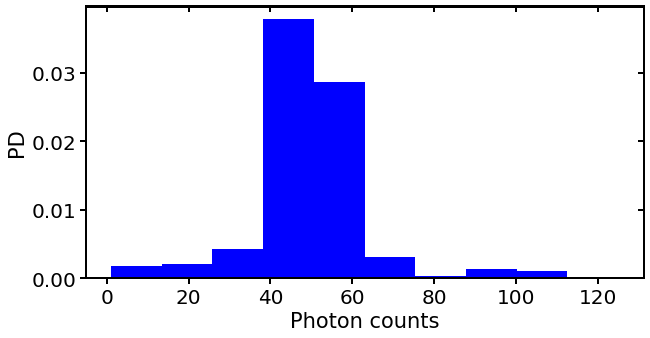

In [25]:
fig, ax = cp.universal_figure(type_="hist", data=measureable_rts_5ms, ylabel="PD", xlabel="Photon counts", density=True)

### Fluorescence correlation spectroscopy

#### Autocorrelation

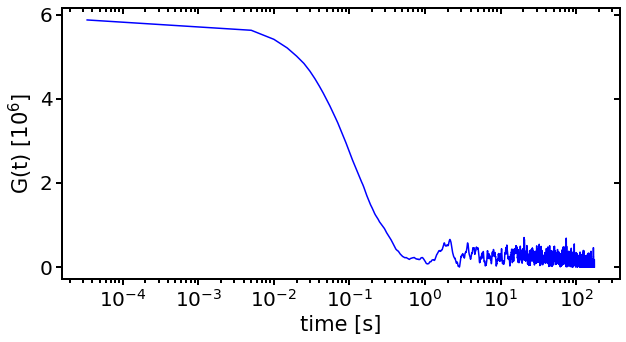

In [71]:
fig, ax = cp.universal_figure(type_="line", data=[resampled_time_series_5ms.index, autocorrelation], xscale="log", 
                              xlabel="time [s]", ylabel="G(t) [$10^{6}$]")
ax.yaxis.get_offset_text().set_visible(False)

### Normalized autocorrelation

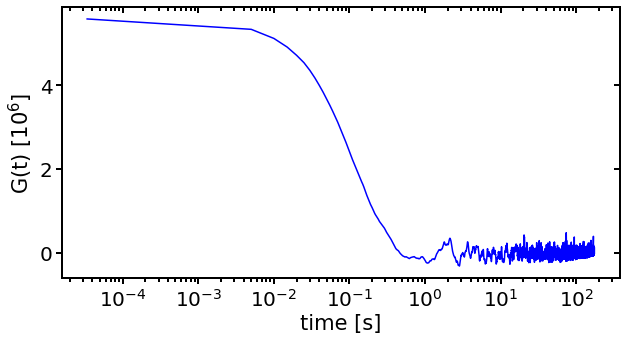

In [86]:
fig, ax = cp.universal_figure(type_="line", data=[resampled_time_series_5ms.index, norm_corr], xscale="log", 
                              xlabel="time [s]", ylabel="G(t) [$10^{6}$]", tick_style_y="sci")

In [138]:
collector = ga.multiple_event_time_series(10, row_sums, initial_row_vector, transition_matrix, 1000000, 100,
                                          emitting_transitions_indices, "5ms")

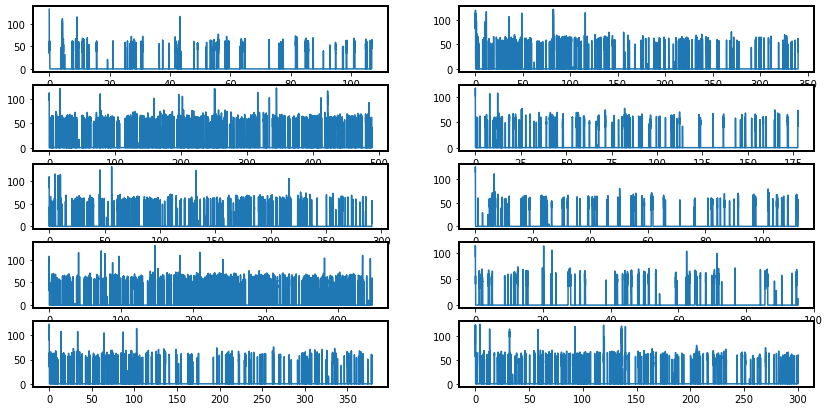

In [139]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 7))
for ax, run in zip(axes.ravel(), collector):
    ax.plot(run.index, run.values)